In [ ]:
# 필요한 라이브러리를 가져옵니다.
from github import Github, RateLimitExceededException, GithubException
import datetime
from dateutil.relativedelta import relativedelta # 날짜 계산을 위해 추가

# --- 1. 사용자 설정 영역 (GitHub API 토큰) ---
# 여기에 GitHub 개인 접근 토큰(PAT)을 입력하세요.
# 예: "YOUR_GITHUB_TOKEN"
# 보안 주의: 토큰을 코드에 직접 넣는 것은 간단한 테스트용이며, 
# 실제 운영 환경에서는 환경 변수나 다른 안전한 방법을 사용하세요.
ACCESS_TOKEN = "YOUR_GITHUB_TOKEN"  # <--- 실제 유효한 토큰으로 교체하세요!

# --- 2. 제공된 검색 조건 ---
SEARCH_KEYWORD_QUERY = '"artificial intelligence" OR "computer vision" OR "deep learning" OR "image recognition" OR "language model"'
MIN_STARS_CONDITION = ">10"
START_DATE_CREATED = "2015-01-01"
END_DATE_CREATED = "2024-12-31"
LAST_PUSHED_WITHIN_MONTHS_AGO = 6 # 예: 최근 6개월 이내 푸시된 저장소

# --- 3. 검색 쿼리 문자열 생성 ---
# 생성 날짜 조건 문자열
created_date_condition_str = f"created:{START_DATE_CREATED}..{END_DATE_CREATED}"

# 마지막 푸시 날짜 조건 문자열 계산
pushed_date_condition_str = ""
if LAST_PUSHED_WITHIN_MONTHS_AGO > 0:
    # 현재 날짜를 기준으로 계산합니다.
    # 이 코드가 실행되는 시점의 '오늘' 날짜를 사용합니다.
    # 제공된 컨텍스트의 현재 날짜: 2025년 5월 15일
    # today_date = datetime.date.today() # 실제 실행 시점의 오늘 날짜
    today_date = datetime.date.today()
    
    pushed_after_this_date = today_date - relativedelta(months=LAST_PUSHED_WITHIN_MONTHS_AGO)
    pushed_date_condition_str = f"pushed:>{pushed_after_this_date.isoformat()}"
    print(f"알림: '마지막 푸시 날짜' 필터가 적용됩니다. 기준 날짜 (이후 푸시): {pushed_after_this_date.isoformat()}")
else:
    print("알림: '마지막 푸시 날짜' 필터가 비활성화되었습니다.")

# 모든 조건을 조합하여 최종 쿼리 문자열 생성
# 각 조건 부분은 공백으로 구분하여 추가합니다.
final_query_parts = [
    SEARCH_KEYWORD_QUERY,
    f"stars:{MIN_STARS_CONDITION}",
    created_date_condition_str
]
if pushed_date_condition_str: # 푸시 날짜 조건이 있는 경우에만 추가
    final_query_parts.append(pushed_date_condition_str)

# 최종 쿼리 문자열
FINAL_QUERY_STRING = " ".join(final_query_parts)
# --- 검색 쿼리 문자열 생성 끝 ---


def fetch_repository_count_with_conditions(api_token, constructed_query):
    """
    주어진 GitHub API 토큰과 구성된 검색 쿼리를 사용하여
    해당 쿼리와 일치하는 저장소의 총 개수를 가져와 출력합니다.
    """

    if not api_token or api_token == "ghp_YOUR_PERSONAL_ACCESS_TOKEN_HERE":
        print("오류: GitHub 접근 토큰이 설정되지 않았습니다.")
        print("스크립트 상단의 'ACCESS_TOKEN' 변수에 실제 유효한 토큰을 입력해주세요.")
        return

    if not constructed_query:
        print("오류: 검색 쿼리가 생성되지 않았거나 비어있습니다.")
        return

    print(f"\n사용될 최종 검색 쿼리: '{constructed_query}'")
    print(f"사용될 토큰 끝 4자리: ...{api_token[-4:] if len(api_token) > 4 else '****'}")
    print("-" * 30)

    try:
        print("GitHub 클라이언트 초기화를 시도합니다...")
        g = Github(api_token)
        core_rate_limit = g.get_rate_limit().core
        
        print(f"현재 API 호출 가능 횟수 (Core): {core_rate_limit.remaining}/{core_rate_limit.limit}")
        reset_time_core = datetime.datetime.fromtimestamp(core_rate_limit.reset)
        print(f"API 호출 제한 리셋 시간 (Core): {reset_time_core.isoformat()}")

        if core_rate_limit.remaining == 0:
            print(f"경고: 현재 API 호출 제한 (Core)에 도달했습니다. {reset_time_core.isoformat()} 이후에 다시 시도해주세요.")
            # return # 여기서 실행 중단 가능
            
    except RateLimitExceededException as rle_init:
        reset_time_display = datetime.datetime.fromtimestamp(int(rle_init.headers['X-RateLimit-Reset'])).isoformat() if rle_init.headers and 'X-RateLimit-Reset' in rle_init.headers else "알 수 없음"
        print(f"클라이언트 초기화 중 API 호출 제한 초과 상태입니다. 리셋 시간: {reset_time_display}")
        return
    except GithubException as ge_init:
        if hasattr(ge_init, 'status') and ge_init.status == 401:
            print("오류: GitHub 토큰이 유효하지 않습니다 (401 Unauthorized).")
        else:
            print(f"클라이언트 초기화 중 GitHub API 오류 발생: {ge_init}")
        return
    except Exception as e_init:
        print(f"클라이언트 초기화 중 예상치 못한 오류 발생: {e_init}")
        return

    print(f"\n쿼리 실행하여 저장소 개수를 가져옵니다...")
    try:
        search_results = g.search_repositories(query=constructed_query)
        repository_count = search_results.totalCount

        print("\n--- 검색 결과 ---")
        print(f"적용된 전체 쿼리: '{constructed_query}'")
        print(f"일치하는 총 저장소 수: {repository_count}")

        if repository_count > 1000:
            print("참고: `totalCount`가 1,000개를 초과하지만, GitHub API는 페이지네이션을 통해")
            print("      처음 1,000개의 항목만 실제로 접근(결과 목록 가져오기) 가능하도록 제한합니다.")
        elif repository_count == 0:
            print("이 조건들과 일치하는 저장소를 찾을 수 없습니다.")

    except RateLimitExceededException as rle_search:
        reset_time_display = datetime.datetime.fromtimestamp(int(rle_search.headers['X-RateLimit-Reset'])).isoformat() if rle_search.headers and 'X-RateLimit-Reset' in rle_search.headers else "알 수 없음"
        print(f"\n저장소 검색 중 API 호출 제한 초과 상태입니다. 리셋 시간: {reset_time_display}")
    except GithubException as ge_search:
        error_message = f"\n저장소 검색 중 GitHub API 오류 발생: Status {ge_search.status if hasattr(ge_search, 'status') else 'N/A'}"
        if hasattr(ge_search, 'data') and 'message' in ge_search.data:
            error_message += f" - {ge_search.data['message']}"
        print(error_message)
        
        if hasattr(ge_search, 'status') and ge_search.status == 422:
            print("  오류 유형: 처리할 수 없는 엔티티 (주로 쿼리 구문이 잘못된 경우 발생합니다).")
            if hasattr(ge_search, 'data') and 'errors' in ge_search.data:
                for err_item in ge_search.data['errors']:
                    print(f"    - 상세: {err_item.get('message')} (리소스: {err_item.get('resource')}, 필드: {err_item.get('field')}, 코드: {err_item.get('code')})")
    except Exception as e_search:
        print(f"\n저장소 검색 중 예상치 못한 오류 발생: {e_search}")


# 스크립트가 직접 실행될 때 함수를 호출합니다.
if __name__ == "__main__":
    print("--- GitHub 저장소 개수 확인 시작 ---")
    print(f"오늘 날짜 (푸시 날짜 계산 기준): {datetime.date(2025, 5, 15).isoformat()} (컨텍스트 제공 날짜 기준)") # 푸시 날짜 계산 기준 명시
    fetch_repository_count_with_conditions(ACCESS_TOKEN, FINAL_QUERY_STRING)
    print("\n--- 확인 완료 ---")

알림: '마지막 푸시 날짜' 필터가 적용됩니다. 기준 날짜 (이후 푸시): 2024-11-15
--- GitHub 저장소 개수 확인 시작 ---
오늘 날짜 (푸시 날짜 계산 기준): 2025-05-15 (컨텍스트 제공 날짜 기준)

사용될 최종 검색 쿼리: '"artificial intelligence" OR "computer vision" OR "deep learning" OR "image recognition" OR "language model" stars:>10 created:2015-01-01..2024-12-31 pushed:>2024-11-15'
사용될 토큰 끝 4자리: ...kKq4
------------------------------
GitHub 클라이언트 초기화를 시도합니다...
현재 API 호출 가능 횟수 (Core): 5000/5000
클라이언트 초기화 중 예상치 못한 오류 발생: 'datetime.datetime' object cannot be interpreted as an integer

--- 확인 완료 ---


In [4]:
from tqdm import tqdm
from github import Github, RateLimitExceededException, BadCredentialsException, GithubException
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import time
import threading
github_tokens =[
    "YOUR_GITHUB_TOKEN",
    "YOUR_GITHUB_TOKEN",
    "YOUR_GITHUB_TOKEN"
]
current_token_index = 0
client_lock = threading.Lock()


def print_token_rate_limits():
    print("\n--- GitHub Token Rate Limits ---")
    for idx, token in enumerate(github_tokens):
        try:
            g = Github(token, timeout=10)
            rate_limit = g.get_rate_limit().core
            print(f"Token {idx}: Remaining = {rate_limit.remaining}, Reset = {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(rate_limit.reset.timestamp()))}")
        except Exception as e:
            print(f"Token {idx}: Failed to get rate limit - {e}")
    print("--- End of Rate Limits ---\n")
print_token_rate_limits()


--- GitHub Token Rate Limits ---
Token 0: Remaining = 5000, Reset = 2025-06-02 15:25:16
Token 1: Remaining = 5000, Reset = 2025-06-02 15:25:17
Token 2: Remaining = 0, Reset = 2025-06-02 15:04:28
--- End of Rate Limits ---



In [7]:
import os
import pandas as pd


data_folder = 'crawled_data_2021_2024'

# 폴더 내 모든 csv 파일 목록 가져오기
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# 각 csv 파일을 DataFrame으로 읽어서 리스트에 저장
df_list = []
for file in csv_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# 모든 DataFrame을 하나로 합치기
df_2124 = pd.concat(df_list, ignore_index=True)

# 결과 확인 (상위 5개 행 출력)
df_2124


,total_index,keyword_source,full_name,html_url,create_date,update_date,pushed_date,language,stars,forks,watchers,open_issues,is_fork,topics,description
0,0,"""multi-modal AI""",MetaSLAM/GPRS_Survey,https://github.com/MetaSLAM/GPRS_Survey,2022-05-19T16:57:15+00:00,2025-05-21T05:28:12+00:00,2024-04-26T23:23:06+00:00,Python,172.0,11.0,172.0,0.0,False,[],Benchmark for lidar and visual place recognition
1,1,"""multi-modal AI""",Kav-K/GPTDiscord,https://github.com/Kav-K/GPTDiscord,2022-12-08T08:06:26+00:00,2025-05-17T16:26:53+00:00,2024-05-30T15:13:04+00:00,Python,1839.0,293.0,1839.0,42.0,False,"['artificial-intelligence', 'asyncio', 'gpt3',...","A robust, all-in-one GPT interface for Discord..."
2,2,"""multi-modal AI""",jina-ai/langchain-serve,https://github.com/jina-ai/langchain-serve,2023-03-21T03:08:56+00:00,2025-05-20T21:09:55+00:00,2023-09-20T04:01:50+00:00,Python,1629.0,139.0,1629.0,15.0,False,"['gpt', 'langchain', 'autonomous-agents', 'fas...",⚡ Langchain apps in production using Jina & Fa...
3,3,"""multi-modal AI""",intel/document-automation,https://github.com/intel/document-automation,2023-04-17T20:39:50+00:00,2024-12-19T06:02:26+00:00,2024-06-27T18:49:15+00:00,Python,14.0,8.0,14.0,0.0,False,"['nlp', 'ocr', 'retrieval', 'odqa', 'semantic-...",Document Automation Reference Kit
4,4,"""multi-modal AI""",liubo12/MultiModal-AI-Chatbot,https://github.com/liubo12/MultiModal-AI-Chatbot,2023-04-26T03:14:06+00:00,2025-02-27T14:17:42+00:00,2023-05-19T06:33:30+00:00,Python,13.0,4.0,13.0,0.0,False,[],多模态对话机器人，支持chatgpt、chatgpt平替、SD等模型进行图文生成，可使用在终...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29538,46,"""responsible AI""",declare-lab/ferret,https://github.com/declare-lab/ferret,2024-08-17T00:22:54+00:00,2025-05-08T01:19:01+00:00,2024-08-22T04:29:47+00:00,Python,15.0,2.0,15.0,1.0,False,"['llm', 'red-teaming', 'safety-alignment']",Ferret: Faster and Effective Automated Red Tea...
29539,47,"""responsible AI""",joshpocock/Stride-AI-Agents,https://github.com/joshpocock/Stride-AI-Agents,2024-10-06T23:26:53+00:00,2025-05-14T15:45:18+00:00,2024-10-15T11:36:22+00:00,Python,316.0,116.0,316.0,1.0,False,"['agents', 'ai', 'aiagent', 'aiagents', 'n8n',...",This Repo Is In Development. It will slowly bu...
29540,48,"""responsible AI""",aws-samples/responsible_ai_reduce_hallucinatio...,https://github.com/aws-samples/responsible_ai_...,2024-10-21T16:37:09+00:00,2025-05-20T17:18:33+00:00,2024-12-10T02:35:45+00:00,Python,27.0,3.0,27.0,1.0,False,['responsible-ai'],Python labs demonstrating various techniques f...
29541,49,"""responsible AI""",aws-samples/Multi-modal-Assistant-With-Advance...,https://github.com/aws-samples/Multi-modal-Ass...,2024-10-01T21:03:19+00:00,2025-05-17T13:48:01+00:00,2024-10-01T21:07:50+00:00,Python,10.0,4.0,10.0,0.0,False,[],NaN


In [6]:
import os
import pandas as pd


data_folder = 'crawled_data_2017_2020'

# 폴더 내 모든 csv 파일 목록 가져오기
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# 각 csv 파일을 DataFrame으로 읽어서 리스트에 저장
df_list = []
for file in csv_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# 모든 DataFrame을 하나로 합치기
df_1720 = pd.concat(df_list, ignore_index=True)

# 결과 확인 (상위 5개 행 출력)
df_1720


,total_index,keyword_source,full_name,html_url,create_date,update_date,pushed_date,language,stars,forks,watchers,open_issues,is_fork,topics,description
0,0,"""causal AI""",softsys4ai/unicorn,https://github.com/softsys4ai/unicorn,2019-03-19T19:21:07+00:00,2024-10-21T06:46:21+00:00,2022-04-10T16:01:27+00:00,Python,42,7,42,4,False,"['machine-learning', 'systems', 'causality', '...",A Framework for Reasoning about System Perform...
1,1,"""causal AI""",shantanu-ai/DPN-SA,https://github.com/shantanu-ai/DPN-SA,2020-06-03T20:41:39+00:00,2025-05-01T00:51:07+00:00,2022-07-28T19:34:37+00:00,Python,11,3,11,0,False,"['autoencoder', 'sparse-autoencoder', 'causal-...",[JAMIA] Official repository of Deep Propensity...
2,0,"""robotics AI""",rockingdingo/gym-gomoku,https://github.com/rockingdingo/gym-gomoku,2017-02-10T09:44:41+00:00,2025-05-20T12:37:04+00:00,2024-10-11T17:00:41+00:00,Python,89,27,89,2,False,[],"OpenAI Gym Env for game Gomoku(Five-In-a-Row, ..."
3,1,"""robotics AI""",jwenjian/ghiblog,https://github.com/jwenjian/ghiblog,2019-04-30T01:25:57+00:00,2025-05-14T14:56:48+00:00,2023-05-08T02:40:10+00:00,Python,349,45,349,292,False,"['blog', 'github-issues-blog', 'python', 'mark...","GitHub Issues Blog, powered by GitHub Issues a..."
4,2,"""robotics AI""",LiveXY/ai-robot,https://github.com/LiveXY/ai-robot,2019-10-19T12:21:05+00:00,2025-04-22T12:20:59+00:00,2020-06-20T06:55:03+00:00,Python,36,7,36,0,False,"['ai-robot', 'snowboy', 'chat-robot', 'music-r...",ai-robot是一个中文人工智能机器人。支持语音唤起、智能音箱、对话机器人
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16656,25,"""explainable AI""",sfschouten/court-of-xai,https://github.com/sfschouten/court-of-xai,2020-07-20T16:20:28+00:00,2023-11-02T14:46:37+00:00,2023-05-30T12:51:00+00:00,Python,11,5,11,1,False,[],Court of XAI - A Python library for the system...
16657,26,"""explainable AI""",abhishek-ch/around-dataengineering,https://github.com/abhishek-ch/around-dataengi...,2020-09-18T12:31:08+00:00,2025-05-18T22:58:40+00:00,2024-02-02T13:09:13+00:00,Python,1128,225,1128,2,False,"['data-engineering', 'machine-learning', 'airf...",A Data Engineering & Machine Learning Knowledg...
16658,27,"""explainable AI""",fhvilshoj/TorchLRP,https://github.com/fhvilshoj/TorchLRP,2020-09-02T12:51:50+00:00,2025-04-22T21:39:10+00:00,2021-02-19T10:21:13+00:00,Python,136,27,136,5,False,"['patternnet', 'pytorch', 'lrp', 'xai', 'expla...",A PyTorch 1.6 implementation of Layer-Wise Rel...
16659,28,"""explainable AI""",XAI-Demonstrator/xai-demonstrator,https://github.com/XAI-Demonstrator/xai-demons...,2020-09-25T13:39:04+00:00,2024-03-18T06:46:48+00:00,2023-12-20T21:00:25+00:00,Python,19,7,19,92,False,"['xai', 'ai', 'explainable-ai', 'mobile-first'...",The XAI Demonstrator is a modular platform tha...


In [8]:
import os
import pandas as pd


data_folder = 'crawled_data_2013_2016'

# 폴더 내 모든 csv 파일 목록 가져오기
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# 각 csv 파일을 DataFrame으로 읽어서 리스트에 저장
df_list = []
for file in csv_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# 모든 DataFrame을 하나로 합치기
df_1316 = pd.concat(df_list, ignore_index=True)

# 결과 확인 (상위 5개 행 출력)
df_1316


,total_index,keyword_source,full_name,html_url,create_date,update_date,pushed_date,language,stars,forks,watchers,open_issues,is_fork,topics,description
0,0,"""artificial intelligence"" OR ""computer vision""...",AdamLaurie/rompar,https://github.com/AdamLaurie/rompar,2013-01-31T12:09:58+00:00,2025-04-01T09:47:30+00:00,2020-08-11T23:19:02+00:00,Python,170,25,170,10,False,[],Semi-automatic extraction of data from microsc...
1,1,"""artificial intelligence"" OR ""computer vision""...",Ecogenomics/CheckM,https://github.com/Ecogenomics/CheckM,2013-02-20T00:43:38+00:00,2025-05-06T15:05:35+00:00,2024-09-03T14:36:02+00:00,Python,371,75,371,23,False,[],Assess the quality of microbial genomes recove...
2,2,"""artificial intelligence"" OR ""computer vision""...",tkisason/unhash,https://github.com/tkisason/unhash,2013-02-25T09:48:58+00:00,2024-05-12T04:56:31+00:00,2022-07-03T15:11:18+00:00,Python,119,18,119,0,False,[],unhash is a set of tools designed to enable be...
3,3,"""artificial intelligence"" OR ""computer vision""...",lukauskas/dtwco,https://github.com/lukauskas/dtwco,2013-02-02T20:33:49+00:00,2024-08-06T06:37:44+00:00,2020-10-06T15:58:28+00:00,Python,43,9,43,3,False,[],dtwco: constrained Dynamic Time Warping implem...
4,4,"""artificial intelligence"" OR ""computer vision""...",andelf/PyAIML,https://github.com/andelf/PyAIML,2013-03-09T16:14:36+00:00,2025-02-21T15:46:53+00:00,2021-09-15T22:25:28+00:00,Python,350,172,350,9,False,[],PyAIML is an interpreter for AIML (Artificial ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006,278,"""natural language processing"" OR ""nlp"" OR ""lan...",TarangKhanna/Wall-Street-Bot,https://github.com/TarangKhanna/Wall-Street-Bot,2016-12-17T20:23:33+00:00,2023-06-11T22:28:01+00:00,2020-09-23T23:20:47+00:00,Python,15,11,15,1,False,"['stock-predictions', 'chatbot', 'machine-lear...",chatbot for stock predictions utilizing machin...
1007,279,"""natural language processing"" OR ""nlp"" OR ""lan...",ebursztein/sitefab,https://github.com/ebursztein/sitefab,2016-12-28T23:47:39+00:00,2024-11-24T21:02:13+00:00,2023-07-25T21:24:16+00:00,Python,12,5,12,91,False,"['website', 'static-site-generator', 'static-s...",A powerful and easy to use cross-platform webs...
1008,0,"""generative AI""",mike-bowles/hdDeepLearningStudy,https://github.com/mike-bowles/hdDeepLearningS...,2016-03-15T04:29:02+00:00,2024-12-19T08:08:43+00:00,2023-11-15T04:55:11+00:00,Python,290,93,290,4,False,[],Code etc for Hacker Dojo Deep Learning Study G...
1009,1,"""generative AI""",rockingdingo/deepnlp,https://github.com/rockingdingo/deepnlp,2016-10-27T07:49:05+00:00,2025-04-22T09:59:06+00:00,2024-10-11T16:02:55+00:00,Python,1354,708,1354,43,False,[],Deep Learning NLP Pipeline implemented on Tens...


keyword_source별 value_counts 결과:
keyword_source
"artificial intelligence" OR "computer vision" OR "deep learning" OR "machine learning" OR "image recognition"    22645
"natural language processing" OR "nlp" OR "language model" OR "speech recognition"                                12013
"generative AI"                                                                                                     372
"explainable AI"                                                                                                     79
"responsible AI"                                                                                                     51
"agentic AI"                                                                                                         41
"multi-modal AI"                                                                                                     20
"robotics AI"                                                                                                   

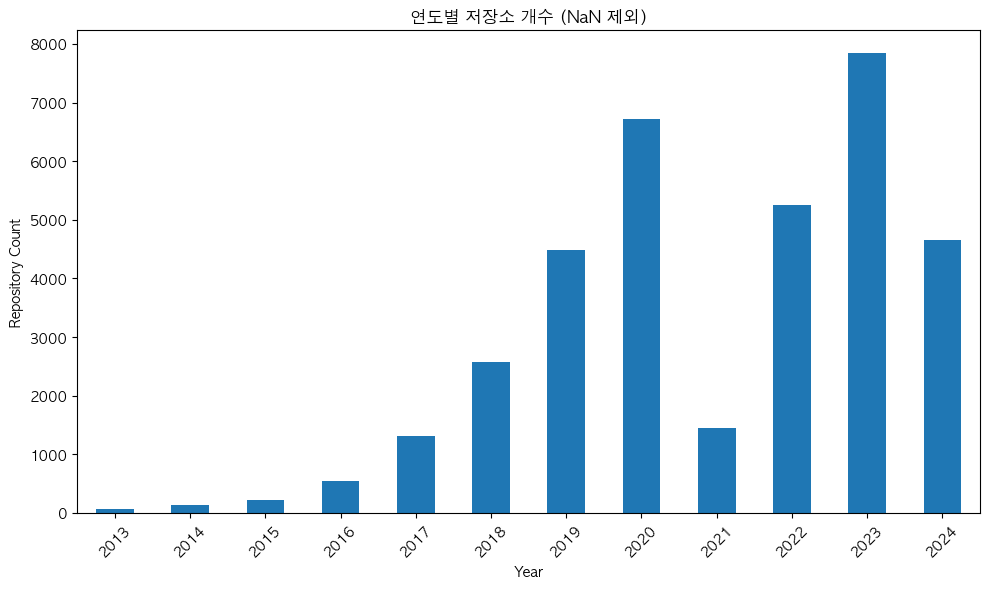

In [14]:
# 연도에 nan을 제외하고 연도의 오름차순으로 카운트 시각화 (애플고딕체 적용)
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (애플고딕)
mpl.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
# 세 시기별로 머지된 데이터프레임을 하나로 합칩니다.
merged_all = pd.concat([df_1316, df_1720, df_2124], ignore_index=True).dropna()

merged_all['year'] = merged_all['create_date'].str[:4]
merged_all['year'] = merged_all['year'].astype(int)
# keyword_source별로 value_counts를 계산합니다.
keyword_counts = merged_all['keyword_source'].value_counts()

# 결과 출력
print("keyword_source별 value_counts 결과:")
print(keyword_counts)
year_counts = merged_all[merged_all['year'].notna()]['year'].astype(int).value_counts().sort_index()

plt.figure(figsize=(10,6))
year_counts.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Repository Count')
plt.title('연도별 저장소 개수 (NaN 제외)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
merged_all

,total_index,keyword_source,full_name,html_url,create_date,update_date,pushed_date,language,stars,forks,watchers,open_issues,is_fork,topics,description,year
0,0,"""artificial intelligence"" OR ""computer vision""...",AdamLaurie/rompar,https://github.com/AdamLaurie/rompar,2013-01-31T12:09:58+00:00,2025-04-01T09:47:30+00:00,2020-08-11T23:19:02+00:00,Python,170.0,25.0,170.0,10.0,False,[],Semi-automatic extraction of data from microsc...,2013
1,1,"""artificial intelligence"" OR ""computer vision""...",Ecogenomics/CheckM,https://github.com/Ecogenomics/CheckM,2013-02-20T00:43:38+00:00,2025-05-06T15:05:35+00:00,2024-09-03T14:36:02+00:00,Python,371.0,75.0,371.0,23.0,False,[],Assess the quality of microbial genomes recove...,2013
2,2,"""artificial intelligence"" OR ""computer vision""...",tkisason/unhash,https://github.com/tkisason/unhash,2013-02-25T09:48:58+00:00,2024-05-12T04:56:31+00:00,2022-07-03T15:11:18+00:00,Python,119.0,18.0,119.0,0.0,False,[],unhash is a set of tools designed to enable be...,2013
3,3,"""artificial intelligence"" OR ""computer vision""...",lukauskas/dtwco,https://github.com/lukauskas/dtwco,2013-02-02T20:33:49+00:00,2024-08-06T06:37:44+00:00,2020-10-06T15:58:28+00:00,Python,43.0,9.0,43.0,3.0,False,[],dtwco: constrained Dynamic Time Warping implem...,2013
4,4,"""artificial intelligence"" OR ""computer vision""...",andelf/PyAIML,https://github.com/andelf/PyAIML,2013-03-09T16:14:36+00:00,2025-02-21T15:46:53+00:00,2021-09-15T22:25:28+00:00,Python,350.0,172.0,350.0,9.0,False,[],PyAIML is an interpreter for AIML (Artificial ...,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47208,44,"""responsible AI""",HyperGAI/HPT,https://github.com/HyperGAI/HPT,2024-03-19T01:31:08+00:00,2025-04-18T12:03:19+00:00,2024-06-06T01:57:52+00:00,Python,315.0,22.0,315.0,9.0,False,"['generative-ai', 'multimodal', 'vision-and-la...",HPT - Open Multimodal LLMs from HyperGAI,2024
47209,45,"""responsible AI""",microsoft/assistant-pf-demo,https://github.com/microsoft/assistant-pf-demo,2024-04-30T12:32:46+00:00,2025-05-20T09:17:53+00:00,2024-07-09T12:03:42+00:00,Python,89.0,40.0,89.0,5.0,False,[],Demo for a Prompt Flow using OpenAI Assistants,2024
47210,46,"""responsible AI""",declare-lab/ferret,https://github.com/declare-lab/ferret,2024-08-17T00:22:54+00:00,2025-05-08T01:19:01+00:00,2024-08-22T04:29:47+00:00,Python,15.0,2.0,15.0,1.0,False,"['llm', 'red-teaming', 'safety-alignment']",Ferret: Faster and Effective Automated Red Tea...,2024
47211,47,"""responsible AI""",joshpocock/Stride-AI-Agents,https://github.com/joshpocock/Stride-AI-Agents,2024-10-06T23:26:53+00:00,2025-05-14T15:45:18+00:00,2024-10-15T11:36:22+00:00,Python,316.0,116.0,316.0,1.0,False,"['agents', 'ai', 'aiagent', 'aiagents', 'n8n',...",This Repo Is In Development. It will slowly bu...,2024


In [17]:
import re
import time
import threading
import pandas as pd
from tqdm import tqdm
from github import Github, RateLimitExceededException, BadCredentialsException, GithubException
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
github_tokens =[
    "YOUR_GITHUB_TOKEN",
    "YOUR_GITHUB_TOKEN",
    "YOUR_GITHUB_TOKEN"
]
current_token_index = 0
client_lock = threading.Lock()

RATE_LIMIT_THRESHOLD = 5  # If remaining requests are below this, rotate token

def print_token_rate_limits():
    print("\n--- GitHub Token Rate Limits ---")
    for idx, token in enumerate(github_tokens):
        try:
            g = Github(token, timeout=10)
            rate_limit = g.get_rate_limit().core
            print(f"Token {idx}: Remaining = {rate_limit.remaining}, Reset = {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(rate_limit.reset.timestamp()))}")
        except Exception as e:
            print(f"Token {idx}: Failed to get rate limit - {e}")
    print("--- End of Rate Limits ---\n")

def get_github_client():
    global current_token_index
    with client_lock:
        for _ in range(len(github_tokens)):
            token = github_tokens[current_token_index]
            try:
                g = Github(token, timeout=20)
                rate_limit = g.get_rate_limit().core
                if rate_limit.remaining <= RATE_LIMIT_THRESHOLD:
                    print(f"[Token {current_token_index}] Rate limit {rate_limit.remaining}. Skipping.")
                else:
                    _ = g.get_user().login  # Trigger 403 if token invalid
                    return g
            except GithubException as e:
                if e.status == 403:
                    print(f"[Token {current_token_index}] 403 Forbidden on login. Rotating...")
                else:
                    print(f"[Token {current_token_index}] GitHubException during login: {e}")
            except Exception as e:
                print(f"[Token {current_token_index}] Unexpected error during login: {e}")
            current_token_index = (current_token_index + 1) % len(github_tokens)
            time.sleep(1)
        raise Exception("All GitHub tokens exhausted or invalid.")

print_token_rate_limits()


--- GitHub Token Rate Limits ---
Token 0: Remaining = 5000, Reset = 2025-06-03 11:26:09
Token 1: Remaining = 3738, Reset = 2025-06-03 11:02:45
Token 2: Remaining = 5000, Reset = 2025-06-03 11:26:09
--- End of Rate Limits ---

